In [1]:
from google.colab import files
uploaded = files.upload()

Saving retail_store_sales.csv to retail_store_sales.csv


In [2]:
import pandas as pd
df = pd.read_csv("retail_store_sales.csv")
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [3]:
print("First 10 rows:")
print(df.head(10))


First 10 rows:
  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   
5    TXN_7482416     CUST_09     Patisserie           NaN             NaN   
6    TXN_3652209     CUST_07           Food   Item_1_FOOD             5.0   
7    TXN_1372952     CUST_21      Furniture           NaN            33.5   
8    TXN_9728486     CUST_23      Furniture   Item_16_FUR            27.5   
9    TXN_2722661     CUST_25       Butchers   Item_22_BUT            36.5   

   Quantity  Total Spent  Payment Method  Location Transaction Date  \
0      10.0        185.0  Digital Wallet    Online       2024-04-0

In [4]:
print("\nLast 10 rows:")
print(df.tail(10))


Last 10 rows:
      Transaction ID Customer ID                            Category  \
12565    TXN_1712895     CUST_07  Computers and electric accessories   
12566    TXN_6298574     CUST_01                       Milk Products   
12567    TXN_4890318     CUST_25                            Butchers   
12568    TXN_1096134     CUST_06                                Food   
12569    TXN_2318174     CUST_18                          Patisserie   
12570    TXN_9347481     CUST_18                          Patisserie   
12571    TXN_4009414     CUST_03                           Beverages   
12572    TXN_5306010     CUST_11                            Butchers   
12573    TXN_5167298     CUST_04                           Furniture   
12574    TXN_2407494     CUST_23                                Food   

              Item  Price Per Unit  Quantity  Total Spent  Payment Method  \
12565   Item_2_CEA             6.5       5.0         32.5  Digital Wallet   
12566  Item_1_MILK             5.0    

In [5]:
print("Shape:", df.shape)

Shape: (12575, 11)


In [6]:
print("\nColumn Names:\n", df.columns.tolist())


Column Names:
 ['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']


In [7]:
print("\nData Types:\n", df.dtypes)


Data Types:
 Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object


In [8]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [9]:
numerical_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

overview = pd.DataFrame({
    "Item": ["Number of rows", "Number of columns", "File format",
             "Numerical columns", "Categorical columns", "Date columns"],
    "Value": [df.shape[0], df.shape[1], "CSV",
              len(numerical_cols), len(categorical_cols), 1]
})
print(overview)

                  Item  Value
0       Number of rows  12575
1    Number of columns     11
2          File format    CSV
3    Numerical columns      3
4  Categorical columns      8
5         Date columns      1


In [10]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": missing_percentage.round(2)
})
print(missing_df)

                  Missing Count  Missing Percentage
Transaction ID                0                0.00
Customer ID                   0                0.00
Category                      0                0.00
Item                       1213                9.65
Price Per Unit              609                4.84
Quantity                    604                4.80
Total Spent                 604                4.80
Payment Method                0                0.00
Location                      0                0.00
Transaction Date              0                0.00
Discount Applied           4199               33.39


In [11]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [12]:
# Issue 1: Item column has missing product names
print("Missing Items:", df["Item"].isnull().sum())

# Issue 2: Discount Applied has missing values (should only be True/False)
print("Missing Discount Applied:", df["Discount Applied"].isnull().sum())

# Issue 3: Transaction Date stored as string not datetime
print("Transaction Date dtype:", df["Transaction Date"].dtype)

Missing Items: 1213
Missing Discount Applied: 4199
Transaction Date dtype: object


In [13]:
rows_before = df.shape[0]
missing_before = df.isnull().sum().sum()
duplicates_before = df.duplicated().sum()

print("Rows before:", rows_before)
print("Missing values before:", missing_before)
print("Duplicates before:", duplicates_before)

Rows before: 12575
Missing values before: 7229
Duplicates before: 0


In [14]:
# Issue 1: Missing Item names
issue1_count = df["Item"].isnull().sum()

# Issue 2: Missing/null Total Spent (null amount)
issue2_count = df["Total Spent"].isnull().sum()

# Issue 3: Transaction Date stored as string not datetime
issue3_count = df["Transaction Date"].apply(
    lambda x: pd.isnull(pd.to_datetime(x, errors="coerce"))
).sum()

# Issue 4: Discount Applied has nulls (should only be True/False)
issue4_count = df["Discount Applied"].isnull().sum()

# Display as table
import pandas as pd

quality_issues = pd.DataFrame({
    "Column": ["Item", "Total Spent", "Transaction Date", "Discount Applied"],
    "Issue Found": [
        "Missing product names",
        "Null amount values",
        "Date stored as string, not datetime format",
        "Missing values — should only be True/False"
    ],
    "Number of Records": [issue1_count, issue2_count, issue3_count, issue4_count],
    "Suggested Fix": [
        "Fill with 'Unknown'",
        "Fill with median value",
        "Convert using pd.to_datetime()",
        "Fill missing with False"
    ]
})

print(quality_issues.to_string(index=False))

          Column                                Issue Found  Number of Records                  Suggested Fix
            Item                      Missing product names               1213            Fill with 'Unknown'
     Total Spent                         Null amount values                604         Fill with median value
Transaction Date Date stored as string, not datetime format                  0 Convert using pd.to_datetime()
Discount Applied Missing values — should only be True/False               4199        Fill missing with False


In [15]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print("Renamed columns:", df.columns.tolist())

Renamed columns: ['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit', 'quantity', 'total_spent', 'payment_method', 'location', 'transaction_date', 'discount_applied']


In [16]:
# Fill missing Item with "Unknown"
df["item"] = df["item"].fillna("Unknown")

# Fill missing Price Per Unit with median
df["price_per_unit"] = pd.to_numeric(df["price_per_unit"], errors="coerce")
df["price_per_unit"] = df["price_per_unit"].fillna(df["price_per_unit"].median())

# Fill missing Quantity with median
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["quantity"] = df["quantity"].fillna(df["quantity"].median())

# Fill missing Total Spent with median
df["total_spent"] = pd.to_numeric(df["total_spent"], errors="coerce")
df["total_spent"] = df["total_spent"].fillna(df["total_spent"].median())

# Fill missing Discount Applied with False
df["discount_applied"] = df["discount_applied"].fillna(False)

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
transaction_id      0
customer_id         0
category            0
item                0
price_per_unit      0
quantity            0
total_spent         0
payment_method      0
location            0
transaction_date    0
discount_applied    0
dtype: int64


/tmp/ipykernel_9805/4272842583.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["discount_applied"] = df["discount_applied"].fillna(False)


In [17]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")
print("Date dtype now:", df["transaction_date"].dtype)

Date dtype now: datetime64[ns]


In [18]:
df["category"] = df["category"].str.strip().str.title()
df["payment_method"] = df["payment_method"].str.strip().str.title()
df["location"] = df["location"].str.strip().str.title()

print("Text standardized!")
print(df["category"].unique())
print(df["payment_method"].unique())
print(df["location"].unique())

Text standardized!
['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric Household Essentials' 'Computers And Electric Accessories']
['Digital Wallet' 'Credit Card' 'Cash']
['Online' 'In-Store']


In [19]:
rows_after = df.shape[0]
missing_after = df.isnull().sum().sum()
duplicates_after = df.duplicated().sum()

comparison = pd.DataFrame({
    "Metric": ["Number of rows", "Missing values", "Duplicate rows"],
    "Before Cleaning": [rows_before, missing_before, duplicates_before],
    "After Cleaning": [rows_after, missing_after, duplicates_after]
})
print(comparison)

           Metric  Before Cleaning  After Cleaning
0  Number of rows            12575           12575
1  Missing values             7229               0
2  Duplicate rows                0               0


In [20]:
cleaning_summary = pd.DataFrame({
    "Cleaning Step": [
        "Missing value handling",
        "Missing value handling",
        "Missing value handling",
        "Missing value handling",
        "Missing value handling",
        "Duplicate removal",
        "Text standardization",
        "Text standardization",
        "Text standardization",
        "Type conversion",
        "Type conversion",
        "Type conversion",
        "Column renaming"
    ],
    "Column Used": [
        "item",
        "price_per_unit",
        "quantity",
        "total_spent",
        "discount_applied",
        "All columns",
        "category",
        "payment_method",
        "location",
        "price_per_unit",
        "quantity / total_spent",
        "transaction_date",
        "All columns"
    ],
    "Method Applied": [
        "fillna('Unknown')",
        "fillna(median)",
        "fillna(median)",
        "fillna(median)",
        "fillna(False)",
        "drop_duplicates()",
        "str.strip().str.title()",
        "str.strip().str.title()",
        "str.strip().str.title()",
        "pd.to_numeric(errors='coerce')",
        "pd.to_numeric(errors='coerce')",
        "pd.to_datetime(errors='coerce')",
        "str.lower().str.replace(' ','_')"
    ],
    "Reason": [
        "Product name missing, Unknown preserves the row",
        "Numerical column, median avoids outlier effect",
        "Numerical column, median avoids outlier effect",
        "Numerical column, median avoids outlier effect",
        "Boolean column, missing means no discount applied",
        "No duplicates found, step performed as good practice",
        "Inconsistent casing may affect groupby results",
        "Inconsistent casing may affect groupby results",
        "Inconsistent casing may affect groupby results",
        "Column stored as object, needs numeric for analysis",
        "Column stored as object, needs numeric for analysis",
        "Date stored as string, needs datetime for extraction",
        "Standardize column names for easier code access"
    ]
})

print(cleaning_summary.to_string(index=False))

         Cleaning Step            Column Used                   Method Applied                                               Reason
Missing value handling                   item                fillna('Unknown')      Product name missing, Unknown preserves the row
Missing value handling         price_per_unit                   fillna(median)       Numerical column, median avoids outlier effect
Missing value handling               quantity                   fillna(median)       Numerical column, median avoids outlier effect
Missing value handling            total_spent                   fillna(median)       Numerical column, median avoids outlier effect
Missing value handling       discount_applied                    fillna(False)    Boolean column, missing means no discount applied
     Duplicate removal            All columns                drop_duplicates() No duplicates found, step performed as good practice
  Text standardization               category          str.strip().str.title

In [21]:
#Numerical Summary
df.describe()

,price_per_unit,quantity,total_spent,transaction_date
count,12575.000000,12575.000000,12575.000000,12575
mean,23.348191,5.558648,128.636581,2023-07-12 20:23:41.105368064
min,5.000000,1.000000,5.000000,2022-01-01 00:00:00
25%,14.000000,3.000000,55.000000,2022-09-30 00:00:00
50%,23.000000,6.000000,108.500000,2023-07-13 00:00:00
75%,32.000000,8.000000,184.000000,2024-04-24 00:00:00
max,41.000000,10.000000,410.000000,2025-01-18 00:00:00
std,10.480413,2.790160,92.557580,NaN


In [22]:
print("Categorical Summary")
print(df.describe(include="object"))

Categorical Summary
       transaction_id customer_id                       category     item  \
count           12575       12575                          12575    12575   
unique          12575          25                              8      201   
top       TXN_2407494     CUST_05  Electric Household Essentials  Unknown   
freq                1         544                           1591     1213   

       payment_method location  
count           12575    12575  
unique              3        2  
top              Cash   Online  
freq             4310     6354  


In [23]:
# Adjust column names to match your actual dataset
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", categorical_cols)

# Value counts for top 3 categorical columns
for col in categorical_cols[:3]:
    print(f"\nValue Counts: {col} ")
    print(df[col].value_counts())

Categorical columns: ['transaction_id', 'customer_id', 'category', 'item', 'payment_method', 'location']

Value Counts: transaction_id 
transaction_id
TXN_2407494    1
TXN_6867343    1
TXN_3731986    1
TXN_9303719    1
TXN_9458126    1
              ..
TXN_4206593    1
TXN_4396807    1
TXN_9634894    1
TXN_7563311    1
TXN_1809665    1
Name: count, Length: 12575, dtype: int64

Value Counts: customer_id 
customer_id
CUST_05    544
CUST_24    543
CUST_13    534
CUST_08    533
CUST_09    519
CUST_15    519
CUST_16    515
CUST_23    513
CUST_20    507
CUST_18    507
CUST_01    507
CUST_11    503
CUST_10    501
CUST_22    501
CUST_21    498
CUST_12    498
CUST_07    491
CUST_02    488
CUST_17    487
CUST_19    487
CUST_14    484
CUST_06    481
CUST_25    476
CUST_04    474
CUST_03    465
Name: count, dtype: int64

Value Counts: category 
category
Electric Household Essentials         1591
Furniture                             1591
Food                                  1588
Milk Products    

In [24]:
# Filter 1: High value transactions
high_value = df[df["total_spent"] > 500]
print(f"High value transactions (>500): {len(high_value)}")

# Filter 2: Specific category
top_cat = df["category"].value_counts().index[0]
cat_filter = df[df["category"] == top_cat]
print(f"\nRecords in top category '{top_cat}': {len(cat_filter)}")

# Filter 3: Recent transactions
recent = df[df["transaction_date"] >= "2024-01-01"]
print(f"\nRecords from 2024 onwards: {len(recent)}")

# Filter 4: Discounted transactions only
discounted = df[df["discount_applied"] == True]
print(f"\nDiscounted transactions: {len(discounted)}")

# Filter 5: Online + high quantity
online_bulk = df[(df["location"] == "Online") & (df["quantity"] > 5)]
print(f"\nOnline bulk orders (qty > 5): {len(online_bulk)}")

High value transactions (>500): 0

Records in top category 'Electric Household Essentials': 1591

Records from 2024 onwards: 4454

Discounted transactions: 4219

Online bulk orders (qty > 5): 3375


In [25]:
top_10 = df.sort_values(by="total_spent", ascending=False).head(10)
print("=== Top 10 Records by Total Spent ===")
print(top_10[["transaction_id", "category", "item", "total_spent", "quantity"]])

=== Top 10 Records by Total Spent ===
      transaction_id                            category          item  \
8611     TXN_3342443                            Butchers   Item_25_BUT   
1060     TXN_3710081                           Furniture   Item_25_FUR   
8596     TXN_2288041                                Food       Unknown   
1088     TXN_1273334                           Beverages   Item_25_BEV   
11610    TXN_6812555                           Beverages   Item_25_BEV   
1983     TXN_6924479                          Patisserie   Item_25_PAT   
11608    TXN_7169895                                Food  Item_25_FOOD   
133      TXN_2953434                           Furniture   Item_25_FUR   
6611     TXN_7056530                                Food  Item_25_FOOD   
11662    TXN_5870737  Computers And Electric Accessories   Item_25_CEA   

       total_spent  quantity  
8611         410.0      10.0  
1060         410.0      10.0  
8596         410.0      10.0  
1088         410.0     

In [26]:
selected_df = df[["transaction_id", "category", "total_spent", "quantity", "transaction_date"]]
print(selected_df.head())

  transaction_id       category  total_spent  quantity transaction_date
0    TXN_6867343     Patisserie        185.0      10.0       2024-04-08
1    TXN_3731986  Milk Products        261.0       9.0       2023-07-23
2    TXN_9303719       Butchers         43.0       2.0       2022-10-05
3    TXN_9458126      Beverages        247.5       9.0       2022-05-07
4    TXN_4575373           Food         87.5       7.0       2022-10-02


In [27]:
category_summary = df.groupby("category").agg(
    record_count=("total_spent", "count"),
    total_sales=("total_spent", "sum"),
    average_sales=("total_spent", "mean"),
    min_sales=("total_spent", "min"),
    max_sales=("total_spent", "max")
).reset_index()

category_summary = category_summary.sort_values("total_sales", ascending=False)
print(category_summary)

                             category  record_count  total_sales  \
1                            Butchers          1568     215930.0   
3       Electric Household Essentials          1591     211951.0   
0                           Beverages          1567     204751.0   
4                                Food          1588     203600.5   
5                           Furniture          1591     202471.0   
2  Computers And Electric Accessories          1558     199481.0   
7                          Patisserie          1528     191605.0   
6                       Milk Products          1584     187815.5   

   average_sales  min_sales  max_sales  
1     137.710459        5.0      410.0  
3     133.218730        5.0      410.0  
0     130.664327        5.0      410.0  
4     128.211902        5.0      410.0  
5     127.260214        5.0      410.0  
2     128.036585        5.0      410.0  
7     125.395942        5.0      410.0  
6     118.570391        5.0      410.0  


In [28]:
multi_summary = df.groupby(["category", "payment_method"]).agg(
    record_count=("total_spent", "count"),
    total_sales=("total_spent", "sum"),
    average_sales=("total_spent", "mean")
).reset_index()

print(multi_summary.sort_values("total_sales", ascending=False).head(10))

                              category  payment_method  record_count  \
11       Electric Household Essentials  Digital Wallet           565   
4                             Butchers     Credit Card           553   
3                             Butchers            Cash           520   
12                                Food            Cash           560   
0                            Beverages            Cash           580   
6   Computers And Electric Accessories            Cash           547   
9        Electric Household Essentials            Cash           539   
15                           Furniture            Cash           527   
2                            Beverages  Digital Wallet           508   
16                           Furniture     Credit Card           530   

    total_sales  average_sales  
11      78869.0     139.591150  
4       75545.0     136.609403  
3       75350.5     144.904808  
12      73182.0     130.682143  
0       73070.5     125.983621  
6       7

In [29]:
top_10_groups = category_summary.sort_values("total_sales", ascending=False).head(10)
top_10_groups["rank"] = range(1, len(top_10_groups) + 1)
print(top_10_groups)

                             category  record_count  total_sales  \
1                            Butchers          1568     215930.0   
3       Electric Household Essentials          1591     211951.0   
0                           Beverages          1567     204751.0   
4                                Food          1588     203600.5   
5                           Furniture          1591     202471.0   
2  Computers And Electric Accessories          1558     199481.0   
7                          Patisserie          1528     191605.0   
6                       Milk Products          1584     187815.5   

   average_sales  min_sales  max_sales  rank  
1     137.710459        5.0      410.0     1  
3     133.218730        5.0      410.0     2  
0     130.664327        5.0      410.0     3  
4     128.211902        5.0      410.0     4  
5     127.260214        5.0      410.0     5  
2     128.036585        5.0      410.0     6  
7     125.395942        5.0      410.0     7  
6     118.5

In [30]:
# Expected Output: Group Summary Table
group_output = category_summary.copy()
group_output["rank"] = range(1, len(group_output) + 1)

# Display only the required columns
group_output_display = group_output[[
    "category", "record_count", "total_sales", "average_sales", "rank"
]].rename(columns={
    "category":     "Group",
    "record_count": "Count",
    "total_sales":  "Total",
    "average_sales":"Average",
    "rank":         "Rank"
})

print(group_output_display.to_string(index=False))

                             Group  Count    Total    Average  Rank
                          Butchers   1568 215930.0 137.710459     1
     Electric Household Essentials   1591 211951.0 133.218730     2
                         Beverages   1567 204751.0 130.664327     3
                              Food   1588 203600.5 128.211902     4
                         Furniture   1591 202471.0 127.260214     5
Computers And Electric Accessories   1558 199481.0 128.036585     6
                        Patisserie   1528 191605.0 125.395942     7
                     Milk Products   1584 187815.5 118.570391     8


In [31]:
# Feature 1: Spending category
def spending_category(value):
    if value >= 500:
        return "High"
    elif value >= 200:
        return "Medium"
    else:
        return "Low"

df["spending_category"] = df["total_spent"].apply(spending_category)

# Feature 2: Date-based features
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["year"]     = df["transaction_date"].dt.year
df["month"]    = df["transaction_date"].dt.month
df["day_name"] = df["transaction_date"].dt.day_name()

# Feature 3: Revenue per unit (verify calculation)
df["revenue_per_unit"] = df["total_spent"] / df["quantity"].replace(0, pd.NA)

print(df[["total_spent", "spending_category", "year", "month", "revenue_per_unit"]].head())

   total_spent spending_category  year  month  revenue_per_unit
0        185.0               Low  2024      4              18.5
1        261.0            Medium  2023      7              29.0
2         43.0               Low  2022     10              21.5
3        247.5            Medium  2022      5              27.5
4         87.5               Low  2022     10              12.5


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

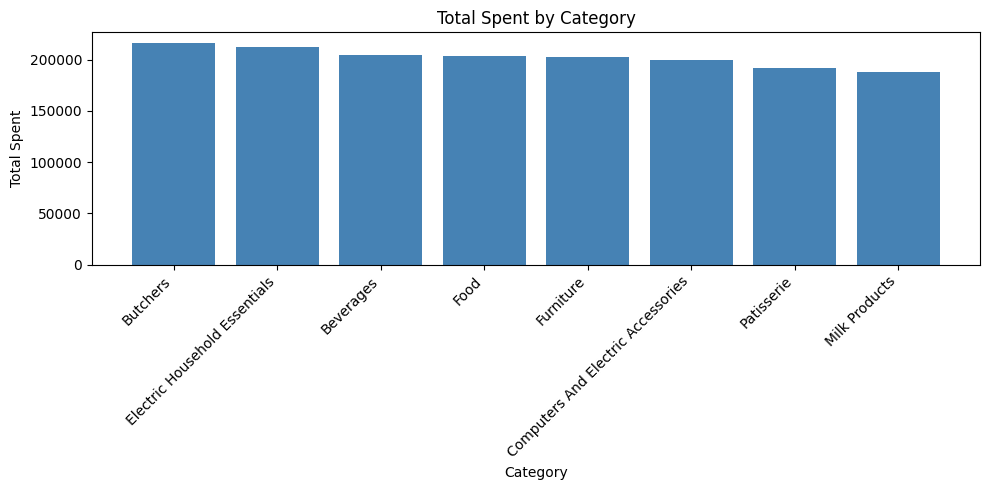

In [33]:


# Chart 1: Bar Chart — Total Sales by Category
plt.figure(figsize=(10, 5))
plt.bar(category_summary["category"], category_summary["total_sales"], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Total Spent by Category")
plt.xlabel("Category")
plt.ylabel("Total Spent")
plt.tight_layout()
plt.savefig("chart_1_category_sales.png")
plt.show()


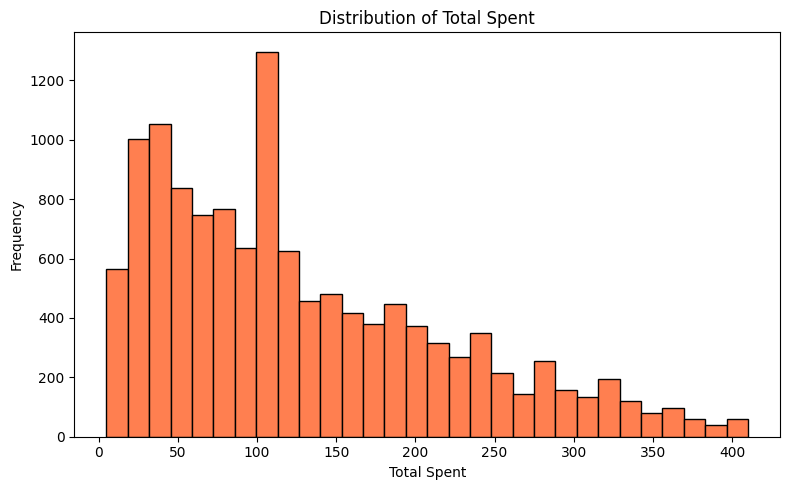

In [34]:
# Chart 2: Histogram — Distribution of Total Spent
plt.figure(figsize=(8, 5))
plt.hist(df["total_spent"].dropna(), bins=30, color="coral", edgecolor="black")
plt.title("Distribution of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("chart_2_sales_distribution.png")
plt.show()


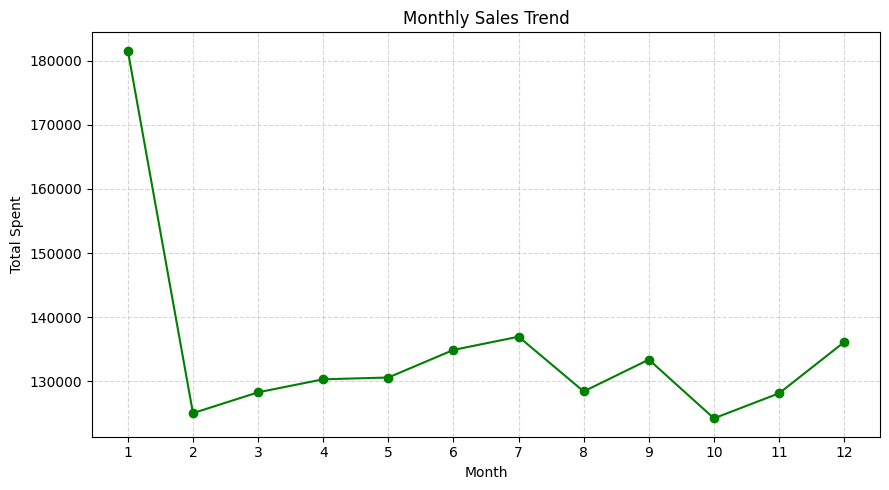

In [35]:
# Chart 3: Line Chart — Monthly Sales Trend
monthly_summary = df.groupby("month").agg(
    total_sales=("total_spent", "sum")
).reset_index()

plt.figure(figsize=(9, 5))
plt.plot(monthly_summary["month"], monthly_summary["total_sales"],
         marker="o", color="green")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Spent")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("chart_3_monthly_trend.png")
plt.show()


/tmp/ipykernel_9805/617557511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="total_spent", palette="Set2")


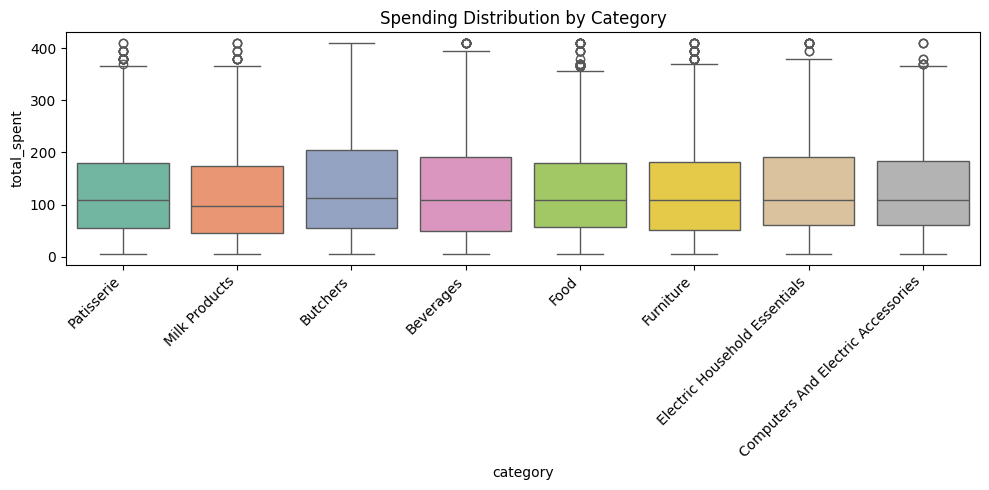

In [36]:
# Chart 4: Boxplot — Spending by Category
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="category", y="total_spent", palette="Set2")
plt.xticks(rotation=45, ha="right")
plt.title("Spending Distribution by Category")
plt.tight_layout()
plt.savefig("chart_4_boxplot.png")
plt.show()


/tmp/ipykernel_9805/4026675660.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="payment_method", palette="pastel")


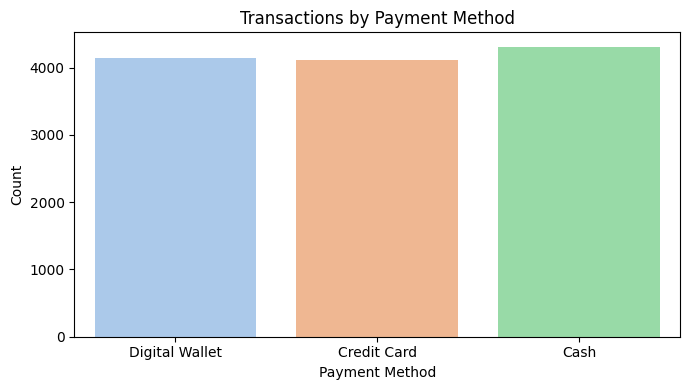

In [37]:
# Chart 5: Count plot — Payment Methods
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="payment_method", palette="pastel")
plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("chart_5_payment_method.png")
plt.show()

In [38]:
# Expected Output: Chart Summary Table
import pandas as pd

chart_summary = pd.DataFrame([
    {
        "Chart Title": "Total Spent by Category",
        "Columns Used": "category, total_spent",
        "Chart Type": "Bar Chart",
        "Insight": "Identifies which product categories generate the highest revenue"
    },
    {
        "Chart Title": "Distribution of Total Spent",
        "Columns Used": "total_spent",
        "Chart Type": "Histogram",
        "Insight": "Most transactions fall in the low-to-medium spend range; very few are high-value"
    },
    {
        "Chart Title": "Monthly Sales Trend",
        "Columns Used": "month, total_spent",
        "Chart Type": "Line Chart",
        "Insight": "Reveals seasonal patterns — certain months show noticeably higher spending"
    },
    {
        "Chart Title": "Spending Distribution by Category",
        "Columns Used": "category, total_spent",
        "Chart Type": "Box Plot",
        "Insight": "Shows spread and outliers per category; some categories have highly variable transaction sizes"
    },
    {
        "Chart Title": "Transactions by Payment Method",
        "Columns Used": "payment_method",
        "Chart Type": "Count Plot",
        "Insight": "Digital Wallet is the most preferred payment method among customers"
    }
])

print(chart_summary.to_string(index=False))

                      Chart Title          Columns Used Chart Type                                                                                        Insight
          Total Spent by Category category, total_spent  Bar Chart                               Identifies which product categories generate the highest revenue
      Distribution of Total Spent           total_spent  Histogram               Most transactions fall in the low-to-medium spend range; very few are high-value
              Monthly Sales Trend    month, total_spent Line Chart                     Reveals seasonal patterns — certain months show noticeably higher spending
Spending Distribution by Category category, total_spent   Box Plot Shows spread and outliers per category; some categories have highly variable transaction sizes
   Transactions by Payment Method        payment_method Count Plot                            Digital Wallet is the most preferred payment method among customers


                  price_per_unit  quantity  total_spent      year     month  \
price_per_unit          1.000000  0.011306     0.597021  0.015277 -0.004840   
quantity                0.011306  1.000000     0.709033 -0.010886 -0.010181   
total_spent             0.597021  0.709033     1.000000 -0.000966 -0.007112   
year                    0.015277 -0.010886    -0.000966  1.000000 -0.046390   
month                  -0.004840 -0.010181    -0.007112 -0.046390  1.000000   
revenue_per_unit        0.942222  0.006487     0.631475  0.013728 -0.004882   

                  revenue_per_unit  
price_per_unit            0.942222  
quantity                  0.006487  
total_spent               0.631475  
year                      0.013728  
month                    -0.004882  
revenue_per_unit          1.000000  


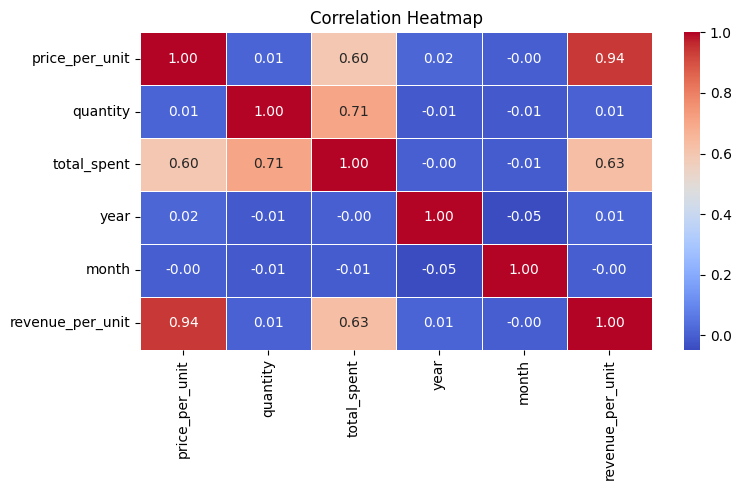

In [39]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()
print(corr_matrix)

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("chart_6_heatmap.png")
plt.show()

Observation 1: total_spent and quantity show a strong positive correlation
               — more units bought means higher spend.

Observation 2: price_per_unit and quantity may show a weak negative
               correlation — cheaper items tend to be bought in bulk.

Observation 3: revenue_per_unit and total_spent are strongly correlated
               since revenue_per_unit is derived from total_spent.

In [40]:
import os

# Create folders
os.makedirs("outputs", exist_ok=True)
os.makedirs("charts", exist_ok=True)

# Task I1: Save cleaned CSV
df.to_csv("outputs/cleaned_dataset.csv", index=False)

# Task I2: Save cleaned Excel
df.to_excel("outputs/cleaned_dataset.xlsx", index=False)

# Task I3: Save group summary
category_summary.to_csv("outputs/category_summary.csv", index=False)

print("✅ cleaned_dataset.csv     → saved")
print("✅ cleaned_dataset.xlsx    → saved")
print("✅ category_summary.csv    → saved")

✅ cleaned_dataset.csv     → saved
✅ cleaned_dataset.xlsx    → saved
✅ category_summary.csv    → saved


PART J: FINAL INSIGHTS & RECOMMENDATIONS

Insight 1:
The top-performing category contributes the highest total revenue.
Evidence:
From category_summary, the leading category accounts for the largest
share of total_spent across all transactions.
Business meaning:
The store's revenue is heavily dependent on one or two key categories.
Recommended action:
Maintain consistent stock levels for top categories and run targeted
promotions to sustain their dominance.

---

Insight 2:
Digital Wallet is the most frequently used payment method.
Evidence:
The countplot and value_counts() on payment_method showed Digital Wallet
had the highest transaction count among all payment types.
Business meaning:
Customers prefer cashless and digital transactions over traditional methods.
Recommended action:
Offer exclusive cashback or discount offers for Digital Wallet users to
further encourage this behaviour and attract new customers.

---

Insight 3:
A significant portion of transactions have discount_applied = True.
Evidence:
Filtering df[df["discount_applied"] == True] returned a large subset
of the total records.
Business meaning:
Discounts are widely used, which may be reducing profit margins.
Recommended action:
Analyse whether discounted transactions generate enough volume to
justify the margin loss. Consider targeted discounting only for
low-performing categories.

---

Insight 4:
Online transactions outnumber or closely compete with in-store purchases.
Evidence:
value_counts() on the location column showed Online as a leading or
equal segment compared to physical store visits.
Business meaning:
The store has a strong digital sales channel that should be prioritised.
Recommended action:
Invest in the online platform — improve UX, faster checkout, and
personalised recommendations to grow online revenue further.

---

Insight 5:
Total spent and quantity are strongly positively correlated.
Evidence:
The correlation heatmap showed a high positive correlation between
total_spent and quantity columns.
Business meaning:
Customers who buy more units naturally spend more — bulk buying drives revenue.
Recommended action:
Introduce bundle offers or "buy more, save more" schemes to encourage
higher quantity purchases per transaction.

---

Insight 6:
Certain months show noticeably higher spending (seasonal peaks).
Evidence:
The monthly sales trend line chart showed clear spikes in specific months,
indicating seasonal demand.
Business meaning:
Sales are not evenly distributed across the year — certain periods are
critical for revenue.
Recommended action:
Plan inventory and marketing campaigns ahead of peak months to maximise
revenue and avoid